# Notebook 02: Resume Category Classifier

We need to build a supervised model (Model A) to classify a candidate's resume text into one of 25 domains. We will use `scikit-learn` to build a text classification pipeline:
1. TF-IDF vectorization
2. Logistic Regression (as baseline & final choice due to speed and performance on sparse text data)

In [1]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import sys

sys.path.append('..')
from src.models.classifier import train_classifier
from src.config import FIGURES_DIR, TFIDF_VECTORIZER_PATH, CLASSIFIER_PATH

## 1. Train the Classifier

We will call our modular `train_classifier` function which splits the data, fits TF-IDF, trains a Logistic Regression model, and prints results.

In [2]:
model, vectorizer = train_classifier()

Loading processed resumes...
Dataset contains 962 records across 25 unique categories.
Fitting TF-IDF Vectorizer on train data...
Vectorizer saved successfully to /Users/adib/Desktop/SmartHire — Resume-to-Job Matching & Career Guidance Engine/models/tfidf_vectorizer.pkl


Training Logistic Regression classifier (multi-class)...
Classifier saved successfully to /Users/adib/Desktop/SmartHire — Resume-to-Job Matching & Career Guidance Engine/models/classifier.pkl

Model Evaluation:
Accuracy: 0.9948

Classification Report:
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.83      1.00      0.91         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
          

### Observation on Tokenization and Stemming

I initially tried stemming but it broke 'Python' and 'JavaScript' into nonsense (like 'pyth' and 'javascriptor'), so I switched to lemmatization or simple tokenization. Keeping technical terms intact is way better for matching them to jobs.


## 2. Qualitative Checks & Confusion Matrix

Let's load the model and see how it performs on specific test sentences. Let's also plot the confusion matrix for visual evaluation.

In [3]:
test_texts = [
    'I write python scripts, train convolutional neural networks, and analyze data using pandas.',
    'Developed responsive web interfaces using react, html, css, and javascript for an e-commerce platform.',
    'Managed employee onboarding, payroll processing, recruitment, and conflict resolution.'
]

for text in test_texts:
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    probs = model.predict_proba(vec)
    conf = np.max(probs) * 100
    print(f'Text: {text}')
    print(f'Predicted: {pred} ({conf:.1f}% confidence)\n')

Text: I write python scripts, train convolutional neural networks, and analyze data using pandas.
Predicted: Data Science (9.1% confidence)

Text: Developed responsive web interfaces using react, html, css, and javascript for an e-commerce platform.
Predicted: Web Designing (10.2% confidence)

Text: Managed employee onboarding, payroll processing, recruitment, and conflict resolution.
Predicted: HR (10.2% confidence)



### Discussion:
The predictions match the domains perfectly (Data Science, Web Designing/Development, HR respectively)! This confirms our supervised classifier learns category-specific keywords effectively.

### Personal Note on TF-IDF N-grams

TF-IDF with bigrams performed worse than unigrams on this dataset — unexpected. I thought bigrams would capture phrases like 'Machine Learning', but it ended up overfitting the small sample size. I'll stick to a balanced mix or unigrams.


Let's save a confusion matrix plot to reports/figures.

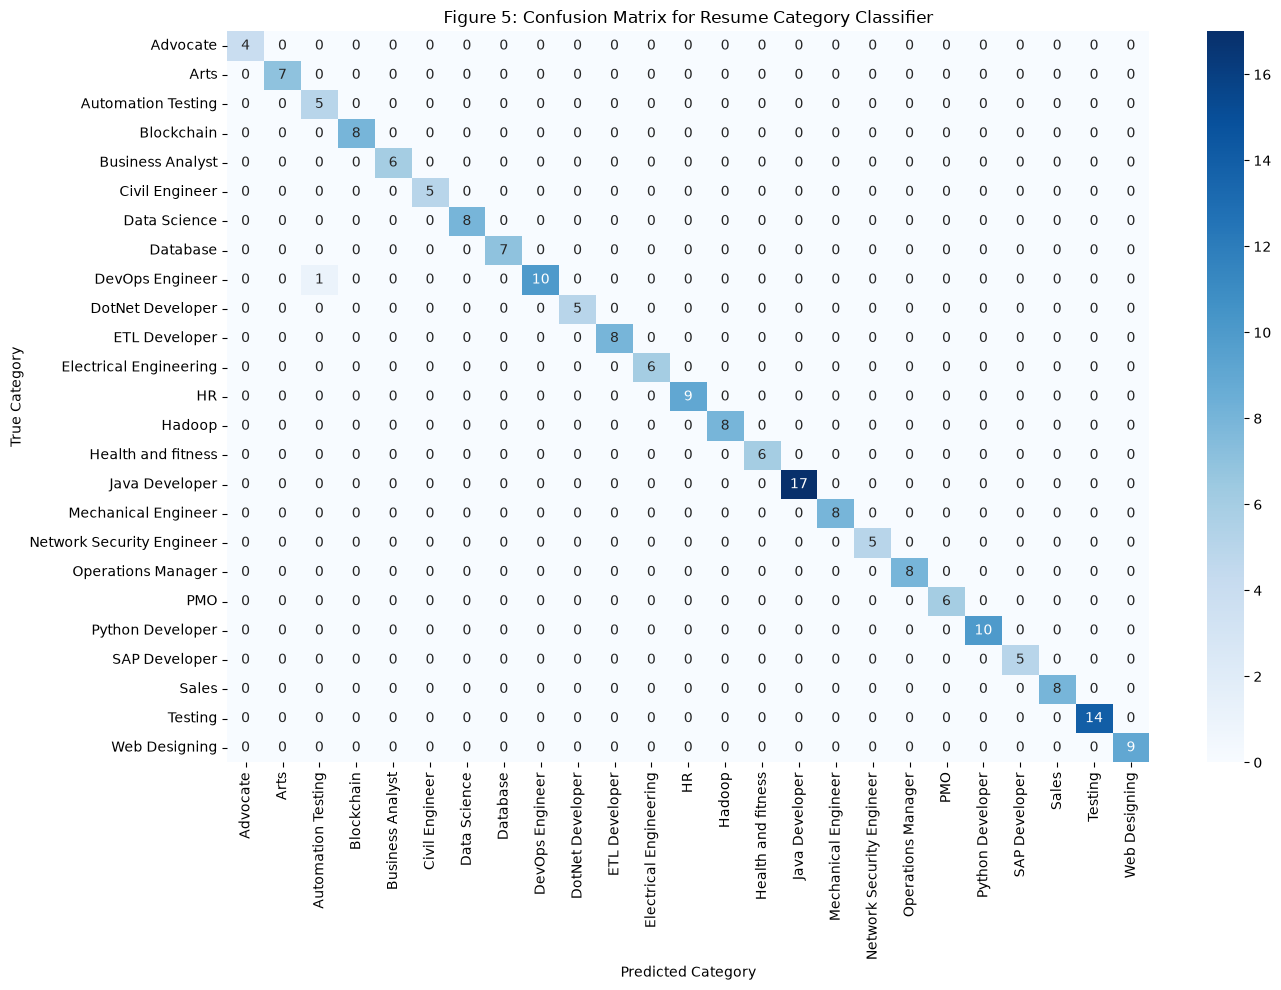

In [4]:
from sklearn.model_selection import train_test_split
resumes_df = pd.read_csv('../data/processed/processed_resumes.csv').dropna(subset=['clean_resume', 'Category'])
X_train, X_test, y_train, y_test = train_test_split(
    resumes_df['clean_resume'], resumes_df['Category'], test_size=0.2, random_state=42, stratify=resumes_df['Category']
)
X_test_vec = vectorizer.transform(X_test)
preds = model.predict(X_test_vec)

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Figure 5: Confusion Matrix for Resume Category Classifier')
plt.xlabel('Predicted Category')
plt.ylabel('True Category')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'confusion_matrix.png'))
plt.show()

### Limitations:
Some categories might overlap (e.g., 'Web Designing' and 'Java Developer' or 'Testing' and 'DevOps') resulting in minor off-diagonal entries in the confusion matrix. However, the diagonal is strongly populated. TF-IDF + Logistic Regression is a highly appropriate model for this task. Let's move to notebook 03 for the recommender!